# Import packages

In [1]:
import numpy as np

import pandas as pd    
import optax 
import jax 
import jax.numpy as jnp   
from jax import grad, jit

# 2D input and 1 output

W shape: (64, 2)
b shape: (64,)
W shape: (64, 64)
b shape: (64,)
W shape: (1, 64)
b shape: (1,)
Epoch 0, Loss = 2.5343e-02
Epoch 200, Loss = 4.3863e-04
Epoch 400, Loss = 1.8261e-04
Epoch 600, Loss = 7.6959e-05
Epoch 800, Loss = 4.5862e-05
Epoch 1000, Loss = 3.1960e-05


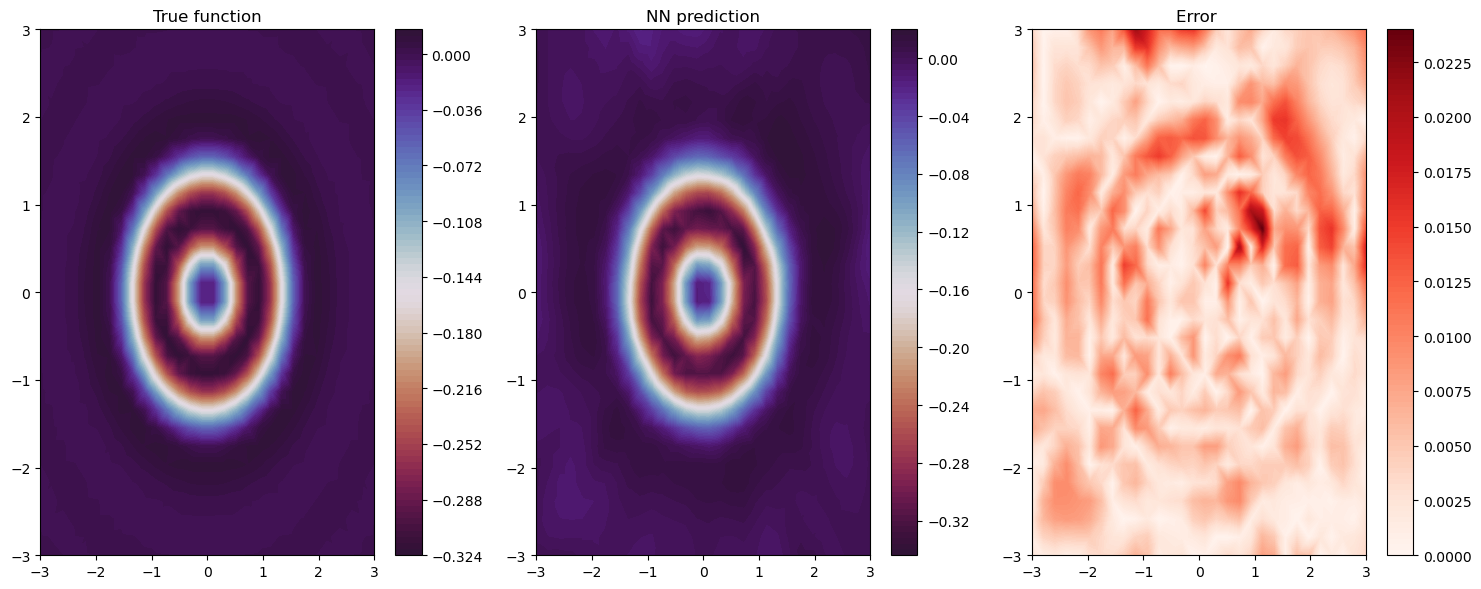

In [2]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt

# ---- 真の関数 ----
def f_true(x, y):
    return jnp.exp(-(x**2 + y**2)) * jnp.sin(-(x**2 + y**2))

# ---- データ ----
key = jax.random.PRNGKey(0)
n_train = 2000
x_train = jax.random.uniform(key, (n_train, 2), minval=-3, maxval=3)
y_train = f_true(x_train[:, 0], x_train[:, 1]).reshape(-1, 1)

# ---- MLP ----
def init_mlp(layer_sizes, key):
    keys = jax.random.split(key, len(layer_sizes))
    params = []
    for m, n, k in zip(layer_sizes[:-1], layer_sizes[1:], keys):
        w_key, _ = jax.random.split(k)
        W = jax.random.normal(w_key, (n, m)) * jnp.sqrt(2/m)
        b = jnp.zeros((n,))
        params.append((W, b))
        print("W shape:",W.shape)
        print("b shape:", b.shape)
    return params

def mlp(params, x):
    for W, b in params[:-1]:
        x = jax.nn.tanh(jnp.dot(x, W.T) + b)
    W, b = params[-1]
    return jnp.dot(x, W.T) + b  # 出力層は線形

# ---- 損失関数 ----
def loss_fn(params, x, y):
    pred = mlp(params, x)
    return jnp.mean((pred - y) ** 2)

# ---- 最適化 ----
lr = 1e-3
optimizer = optax.adam(lr)
params = init_mlp([2, 64, 64, 1], key)
opt_state = optimizer.init(params)

@jax.jit
def update(params, opt_state, x, y):
    grads = jax.grad(loss_fn)(params, x, y)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state

# ---- ミニバッチ学習 ----
def data_loader(x, y, batch_size, key):
    idx = jax.random.permutation(key, len(x))
    for i in range(0, len(x), batch_size):
        batch_idx = idx[i:i+batch_size]
        yield x[batch_idx], y[batch_idx]

# ---- 学習ループ ----
for epoch in range(1001):
    for xb, yb in data_loader(x_train, y_train, 128, key):
        params, opt_state = update(params, opt_state, xb, yb)
    if epoch % 200 == 0:
        l = loss_fn(params, x_train, y_train)
        print(f"Epoch {epoch}, Loss = {l:.4e}")

# ---- 可視化 ----
x = jnp.linspace(-3, 3, 30)
y = jnp.linspace(-3, 3, 30)

# 全組み合わせを作成
X = jnp.repeat(x, len(y))
Y = jnp.tile(y, len(x))
XY = jnp.stack([X, Y], axis=1)

# 予測と真値を計算
Z_true = f_true(XY[:, 0], XY[:, 1])
Z_pred = jax.vmap(lambda x: mlp(params, x))(XY).flatten()


# ---- プロット ----
fig, axs = plt.subplots(1, 3, figsize=(15, 6))
im0 = axs[0].tricontourf(XY[:,0], XY[:,1], Z_true, cmap = "twilight_shifted_r",levels = 100)
axs[0].set_title("True function")
im1 = axs[1].tricontourf(XY[:,0], XY[:,1], Z_pred, cmap = "twilight_shifted_r",levels = 100)
axs[1].set_title("NN prediction")

im2 = axs[2].tricontourf(XY[:,0], XY[:,1], np.abs(Z_pred-Z_true), cmap = "Reds",levels = 100)
axs[2].set_title("Error ")

plt.colorbar(im0, ax=axs[0])
plt.colorbar(im1, ax=axs[1])
plt.colorbar(im2, ax=axs[2])
plt.tight_layout()
plt.show()


In [3]:
Z_pred = jax.vmap(jax.grad(lambda x: mlp(params, x)[0]))(XY)


In [42]:
np.array(params[0][0]).shape

(64, 2)

In [50]:
import numpy as np
import pandas as pd

# ---- グリッド設定 ----
n_points = 11  # 各軸の分割数（例: 0.0, 0.1, ..., 1.0）
x = np.linspace(0.0, 1.0, n_points)
y = np.linspace(0.0, 1.0, n_points)
z = np.linspace(0.0, 1.0, n_points)

# ---- メッシュ生成 ----
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# ---- DataFrame化 ----
data = np.column_stack((X.flatten(), Y.flatten(), Z.flatten()))
df = pd.DataFrame(data, columns=['x', 'y', 'z'])

# ---- データ分割（例: 80%訓練, 20%テスト）----
n_train = int(len(df) * 0.8)
df_train = df.iloc[:n_train].reset_index(drop=True)
df_test = df.iloc[n_train:].reset_index(drop=True)

# ---- CSV出力（任意）----
df_train.to_csv('train_points.csv', index=False)
df_test.to_csv('test_points.csv', index=False)

print("Train data:", df_train.shape)
print("Test data:", df_test.shape)
print(df_train.head())



Train data: (1064, 3)
Test data: (267, 3)
     x    y    z
0  0.0  0.0  0.0
1  0.0  0.0  0.1
2  0.0  0.0  0.2
3  0.0  0.0  0.3
4  0.0  0.0  0.4


In [1]:
import numpy as np
import pandas as pd
import jax.numpy as jnp
import h5py
import inspect
import jax # Import jax for PRNGKey

class TrainingDataManager:
    """
    トレーニングデータを設定、抽出し、管理するためのクラス。
    境界条件、物理情報、ランダムな点の生成、およびデータの結合をサポートします。
    """

    def __init__(self, df_full: pd.DataFrame, data_step: int = 1, physics_step: int = 1, dimensions = 3):
        """
        TrainingDataManagerのコンストラクタ

        Args:
            df_full (pd.DataFrame): 元となる全てのデータを含むデータフレーム。
            data_step (int): データ抽出の間隔（一般的なサンプリング用）。
            physics_step (int): 物理情報抽出の間隔。
        """
        self.df_full = df_full
        self.data_step = data_step
        self.physics_step = physics_step

        self.training_data = {}
        self._boundary_conditions_config = {}
        self._filtered_points_configs = {}
        self._physics_config = None
        self._random_points_configs = {} # Dictionary to store multiple random point configs
        self._grid_points_configs = {}
        self._observed_points_configs = {} # Dictionary to store multiple observed point configs
        self._concatenation_configs = []
        self._equation_func_for_filtered = {} # Store functions for equation-based filtered points
        self.dimensions = dimensions

    def _internal_extractor(self, pandas_dataframe: pd.DataFrame, condition_indices: np.ndarray) -> pd.DataFrame:
        """
        内部で使用するextractor関数。データフレームから指定されたインデックスの行を抽出します。
        """
        return pandas_dataframe.iloc[condition_indices]

    def _internal_stokes_data_conversion(self, df_data: pd.DataFrame) -> dict:
        """
        内部で使用するStokesデータ変換関数。
        データフレームから利用可能なStokes流体変数を抽出し、JAX NumPy配列の辞書に変換します。
        DataFrameに列が存在しない場合は、その変数は含まれません。
        """
        data = {}
        cols_to_check = ['x', 'y', 'u', 'v', 'p']
        if self.dimensions == 3:
            cols_to_check.extend(['z', 'w'])

        for col in cols_to_check:
            if col in df_data.columns:
                data[col] = jnp.array(df_data[col].values)
        return data

    def _create_stacked_data(self, df_subset: pd.DataFrame, z_cols: list, step: int = 1) -> tuple[jnp.ndarray, jnp.ndarray]:
        """
        データフレームのサブセットからX (座標) とZ (目的変数) を作成します。

        Args:
            df_subset (pd.DataFrame): 処理対象のデータフレームのサブセット。
            z_cols (list): ZにJAX NumPy配列として結合する列名のリスト（例: ['u', 'v', 'p']）。
            step (int, optional): データのサンプリング間隔。デフォルトは1（全て使用）。

        Returns:
            tuple: (X_stacked, Z_stacked) のタプル。
        """
        if df_subset.empty:
            empty_shape_x = (0, self.dimensions)
            empty_shape_z = (0, len(z_cols))
            return jnp.empty(empty_shape_x), jnp.empty(empty_shape_z)

        coords_list = [jnp.array(df_subset['x'].values)[::step], jnp.array(df_subset['y'].values)[::step]]
        if self.dimensions == 3:
            coords_list.append(jnp.array(df_subset['z'].values)[::step])
        X_stacked = jnp.column_stack(coords_list)

        z_data_list = []
        stokes_data_dict = self._internal_stokes_data_conversion(df_subset)

        for col in z_cols:
            if col in stokes_data_dict:
                z_data_list.append(stokes_data_dict[col][::step])
            elif col in df_subset.columns: # df_data自体に目的変数がある場合
                z_data_list.append(jnp.array(df_subset[col].values)[::step])
            else: # 指定された列がデータフレームに存在しない場合、ゼロ配列を追加
                if X_stacked.shape[0] > 0:
                    z_data_list.append(jnp.zeros_like(X_stacked[:, 0]))
                else:
                    z_data_list.append(jnp.empty(0))

        if z_data_list and all(arr.size > 0 for arr in z_data_list):
            Z_stacked = jnp.column_stack(z_data_list)
        elif X_stacked.shape[0] > 0:
            Z_stacked = jnp.zeros((X_stacked.shape[0], len(z_cols)))
        else:
            Z_stacked = jnp.empty((0, len(z_cols)))

        return X_stacked, Z_stacked

    def add_random_points_config(self, name: str, num_points: int, *ranges: tuple, z_cols: list = None, seed: int = 22, z_values: list = None):
        """
        任意次元の範囲内にランダムな点を生成し、対応するZをゼロまたは指定値で生成します。
        jAX.random を使用し、keyを外部から入力できるようにします。

        Args:
            name (str): このランダムデータセットに付ける一意の名前。
            num_points (int): 生成する点の数
            *ranges: 各次元ごとの(min, max)タプル。例: x_range, y_range, z_range,...
            z_cols (list, optional): Zの列名リスト。指定しない場合、デフォルトの物理量列が使用されます。
            seed (int, optional): JAXのPRNGKeyを生成するためのシード。デフォルトは22。
            z_values (list or None, optional): Zの各列に設定する値のリスト。例: [1,0,0,1,2]。
                                                Noneの場合、Zはゼロで埋められます。
        """
        if name in self._random_points_configs:
            raise ValueError(f"Random points config with name '{name}' already exists. Please choose a unique name.")
        self._random_points_configs[name] = {
            "num_points": num_points,
            "ranges": ranges,
            "z_cols": z_cols,
            "seed": seed,
            "z_values": z_values
        }

    def _generate_random_points(self, name: str) -> tuple[jnp.ndarray, jnp.ndarray]:
        """
        add_random_points_configで設定された情報に基づいてランダムな点を生成する内部メソッド。
        """
        config = self._random_points_configs.get(name)
        if config is None:
            raise ValueError(f"Config for '{name}' not found. Please call add_random_points_config first.")

        num_points = config["num_points"]
        ranges = config["ranges"]
        z_cols = config["z_cols"]
        seed = config["seed"]
        z_values = config["z_values"]

        key = jax.random.PRNGKey(seed)
        if len(ranges) != self.dimensions:
            raise ValueError(f"{self.dimensions}次元に対して{len(ranges)}個の範囲が必要です。")

        if z_cols is None:
            z_cols = [f"f{chr(ord('x')+i)}" for i in range(self.dimensions)] + ["mass_conservation"]

        keys = jax.random.split(key, self.dimensions)
        coords_list = [
            jax.random.uniform(keys[i], (num_points,), minval=ranges[i][0], maxval=ranges[i][1])
            for i in range(self.dimensions)
        ]

        X_random = jnp.column_stack(coords_list)

        if z_values is not None:
            if len(z_values) != len(z_cols):
                raise ValueError("z_valuesの長さはz_colsの長さと一致する必要があります。")
            Z_random = jnp.tile(jnp.array(z_values), (num_points, 1))
        else:
            Z_random = jnp.zeros((num_points, len(z_cols)))

        return X_random, Z_random


    def add_grid_points_config(
        self,
        *,
        name: str = "grid",
        num_points_per_dim,
        ranges,
        z_cols=None,
        z_values=None):

        """
        任意次元の範囲内に等間隔な格子点を生成し、対応するZをゼロまたは指定値で生成します。

        Args:
            name (str): このグリッドデータセットに付ける一意の名前。
            num_points_per_dim (int or list): 各次元ごとの点の数（intの場合は全次元共通、listの場合は各次元ごと）。
            ranges: 各次元ごとの(min, max)タプル。例: x_range, y_range, z_range,...
            z_cols (list, optional): Zの列名リスト。
            z_values (list or None, optional): Zの各列に設定する値のリスト。例: [1,0,0,1,2]。
                                                Noneの場合、Zはゼロで埋められます。
        """
        if name in self._grid_points_configs:
            raise ValueError(f"Grid points config with name '{name}' already exists. Please choose a unique name.")
        self._grid_points_configs[name] = {
            "num_points_per_dim": num_points_per_dim,
            "ranges": ranges,
            "z_cols": z_cols,
            "z_values": z_values,
        }

    def _generate_grid_points(self, name: str):
        """
        add_grid_points_configで設定された情報に基づいて格子点を生成する内部メソッド。
        """
        config = self._grid_points_configs.get(name)
        if config is None:
            raise ValueError(f"Config for '{name}' not found. Please call add_grid_points_config first.")
        
        num_points_per_dim = config["num_points_per_dim"]
        ranges = config["ranges"]
        z_cols = config["z_cols"]
        z_values = config["z_values"]

        if len(ranges) != self.dimensions:
            raise ValueError(f"{self.dimensions}次元に対して{len(ranges)}個の範囲が必要です。")

        if isinstance(num_points_per_dim, int):
            num_points_list = [num_points_per_dim] * self.dimensions
        elif isinstance(num_points_per_dim, (list, tuple)) and len(num_points_per_dim) == self.dimensions:
            num_points_list = list(num_points_per_dim)
        else:
            raise ValueError("num_points_per_dimはintまたは各次元ごとのリスト/タプルで指定してください。")

        grids = [
            jnp.linspace(ranges[i][0], ranges[i][1], num_points_list[i])
            for i in range(self.dimensions)
        ]
        mesh = jnp.meshgrid(*grids, indexing='ij')
        X_grid = jnp.stack([m.reshape(-1) for m in mesh], axis=1)

        if z_cols is None:
            z_cols = [f"f{chr(ord('x')+i)}" for i in range(self.dimensions)] + ["mass_conservation"]

        if z_values is not None:
            if len(z_values) != len(z_cols):
                raise ValueError("z_valuesの長さはz_colsの長さと一致する必要があります。")
            Z_grid = jnp.tile(jnp.array(z_values), (X_grid.shape[0], 1))
        else:
            Z_grid = jnp.zeros((X_grid.shape[0], len(z_cols)))

        return X_grid, Z_grid

    # --- 新しく追加するメソッド ---
    def add_observed_points_config(self, name: str, num_points: int, z_columns: list, seed: int = 1145148101919):
        """
        元のDataFrameからランダムに点を抽出し、指定された物理量をZとして設定します。
        これらの点は、観測データ（真値）としてPINNの学習に使用されます。

        Args:
            name (str): この観測データセットに付ける一意の名前。
            num_points (int): 抽出する点の総数。
            z_columns (list): 抽出したい物理量（u, v, w, pなど）の列名のリスト。
            seed (int, optional): ランダムサンプリングのためのシード値。デフォルトは42。
        """
        if name in self._observed_points_configs:
            raise ValueError(f"Observed points config with name '{name}' already exists. Please choose a unique name.")
        # num_pointsがdf_fullの行数を超える場合、最大行数に制限する
        if num_points > len(self.df_full):
            print(f"Warning: 要求された観測点数 ({num_points}) が全データ数 ({len(self.df_full)}) を超えています。全データ数を上限とします。")
            num_points = len(self.df_full)

        self._observed_points_configs[name] = {
            "num_points": num_points,
            "z_columns": z_columns,
            "seed": seed
        }

    def _generate_observed_points(self, name: str) -> tuple[jnp.ndarray, jnp.ndarray]:
        """
        add_observed_points_configで設定された情報に基づいて観測点を生成する内部メソッド。
        """
        config = self._observed_points_configs.get(name)
        if config is None:
            raise ValueError(f"Config for '{name}' not found. Please call add_observed_points_config first.")

        num_points = config["num_points"]
        z_columns = config["z_columns"]
        seed = config["seed"]

        # NumPyのrandom.choiceを使用して、データフレームのインデックスをランダムにサンプリング
        rng = np.random.default_rng(seed)
        sampled_indices = rng.choice(self.df_full.index, size=num_points, replace=False) # 重複なしでサンプリング

        df_subset = self.df_full.loc[sampled_indices] # サンプリングされたインデックスの行を抽出

        # _create_stacked_data を再利用してXとZを作成
        X_observed, Z_observed = self._create_stacked_data(df_subset, z_columns, step=1)

        return X_observed, Z_observed

    def add_filtered_points_config(self,
                                   name: str,
                                   num_points: int,
                                   z_cols: list,
                                   from_dataframe: bool = True, # Moved this earlier
                                   filter_condition_func: callable = None, # Moved this later
                                   z_values: list = None,
                                   seed: int = 42,
                                   equation_params: dict = None):
        """
        ラムダ関数などのフィルタリング条件に基づいてDataFrameから点を抽出するか、
        等間隔の点を生成し、指定されたZの値を設定します。

        Args:
            name (str): このフィルタリングされたデータセットに付ける一意の名前。
            filter_condition_func (callable, optional): DataFrameを引数に取り、ブールSeriesまたは
                                                    ブールNumpy配列を返す関数（例: lambda df: df['x'] == 0）。
                                                    from_dataframe=Trueの場合に必要。
            num_points (int): 抽出または生成する点の数。条件に合致する点の数がこれより少ない場合は、
                                合致する全ての点が使用されます。
            z_cols (list): ZにJAX NumPy配列として結合する列名のリスト。
            z_values (list or None, optional): Zの各列に設定する値のリスト。
                                                Noneの場合、Zはゼロで埋められます。
                                                要素が単一の値の場合、それが全ての点に適用されます。
                                                要素がnp.ndarrayの場合、その配列の長さはnum_pointsと
                                                一致する必要があります。
            seed (int, optional): ランダムサンプリングのためのシード。from_dataframe=Trueの場合のみ有効。
                                    デフォルトは42。
            from_dataframe (bool, optional): Trueの場合、元のDataFrameから点をランダムに抽出します。
                                                Falseの場合、equation_paramsに基づいて等間隔の点を生成します。
                                                デフォルトはTrue。
            equation_params (dict, optional): from_dataframe=Falseの場合に必要。
                                                点を生成するための式のパラメータを含む辞書。
                                                例: {"func": your_equation_function, "x_range": (0, 1), "y_range": (0, 1)}
                                                "func"は (x, y, t) -> (u, v, w, p) の形式の関数を想定。
                                                filter_condition_funcの代わりに使用されます。
        """
        if name in self._filtered_points_configs:
            raise ValueError(f"Filtered points config with name '{name}' already exists. Please choose a unique name.")

        if from_dataframe:
            if filter_condition_func is None:
                raise ValueError("from_dataframe=Trueの場合、filter_condition_funcを指定する必要があります。")
            config = {
                "filter_condition_func": filter_condition_func,
                "num_points": num_points,
                "z_cols": z_cols,
                "z_values": z_values,
                "seed": seed,
                "from_dataframe": True
            }
        else:
            if equation_params is None or "func" not in equation_params:
                raise ValueError("from_dataframe=Falseの場合、equation_paramsに'func'（点を生成する関数）が必要です。")
            
            required_ranges = ["x_range", "y_range"]
            if self.dimensions == 3:
                required_ranges.append("z_range") # For 3D spatial, it's z_range, not t_range
            
            if not all(key in equation_params for key in required_ranges):
                raise ValueError(f"from_dataframe=Falseの場合、equation_paramsには{required_ranges}のキーが必要です。")
            
            config = {
                "num_points": num_points,
                "z_cols": z_cols,
                "z_values": z_values,
                "from_dataframe": False,
                "equation_params": equation_params
            }
            self._equation_func_for_filtered[name] = equation_params["func"] # Store the function by name

        self._filtered_points_configs[name] = config

    def _generate_filtered_points(self,
                                  name: str) -> tuple[jnp.ndarray, jnp.ndarray]:
        """
        add_filtered_points_configで設定された情報に基づいてフィルタリングされた点を生成する内部メソッド。
        Args:
            name (str): 生成するフィルタリングされたデータセットの名前。
        """
        config = self._filtered_points_configs.get(name)
        if config is None:
            raise ValueError(f"Config for '{name}' not found. Please call add_filtered_points_config first.")

        num_points = config["num_points"]
        z_cols = config["z_cols"]
        z_values = config["z_values"]

        if config["from_dataframe"]:
            filter_condition_func = config["filter_condition_func"]
            seed = config["seed"]

            # フィルタリング条件を適用
            condition_bool_array = filter_condition_func(self.df_full)

            if not isinstance(condition_bool_array, (np.ndarray, pd.Series, jax.Array)) or condition_bool_array.dtype != bool:
                raise TypeError("filter_condition_func はブール配列またはブールSeriesを返す必要があります。")

            # 条件に合致する点のインデックスを取得
            matching_indices = np.where(condition_bool_array)[0]

            # 抽出する点の数を制限
            if len(matching_indices) > num_points:
                rng = np.random.default_rng(seed)
                sampled_indices = rng.choice(matching_indices, size=num_points, replace=False)
            else:
                sampled_indices = matching_indices
                if len(matching_indices) < num_points:
                    print(f"Info: 条件に合致する点が指定数 ({num_points}) より少ないため、全ての合致点 ({len(matching_indices)}) を使用します。")

            df_subset = self.df_full.iloc[sampled_indices]

            # X座標の抽出
            coords_list = [jnp.array(df_subset['x'].values), jnp.array(df_subset['y'].values)]
            if self.dimensions == 3:
                if 'z' in df_subset.columns: # Assume 'z' for 3D spatial data
                    coords_list.append(jnp.array(df_subset['z'].values))
                elif 't' in df_subset.columns: # Fallback to 't' if it's a time-dependent problem
                    coords_list.append(jnp.array(df_subset['t'].values))
                else:
                    raise ValueError("3Dデータの場合、'z'または't'列が必要です。")
            X_filtered = jnp.column_stack(coords_list)

        else: # Generate from equation
            equation_params = config["equation_params"]
            func = self._equation_func_for_filtered[name]
            
            # Determine number of points per dimension for even spacing
            num_per_dim = int(np.cbrt(num_points)) if self.dimensions == 3 else int(np.sqrt(num_points))

            ranges_from_params = [equation_params["x_range"], equation_params["y_range"]]
            if self.dimensions == 3:
                # Use 'z_range' for 3D spatial, fallback to 't_range'
                ranges_from_params.append(equation_params.get("z_range", equation_params.get("t_range"))) 

            linspace_coords = [np.linspace(r[0], r[1], num_per_dim) for r in ranges_from_params]
            
            if self.dimensions == 2:
                X_mesh, Y_mesh = np.meshgrid(linspace_coords[0], linspace_coords[1])
                X_filtered = jnp.array(np.vstack([X_mesh.ravel(), Y_mesh.ravel()]).T)
            elif self.dimensions == 3:
                X_mesh, Y_mesh, Z_mesh = np.meshgrid(linspace_coords[0], linspace_coords[1], linspace_coords[2])
                X_filtered = jnp.array(np.vstack([X_mesh.ravel(), Y_mesh.ravel(), Z_mesh.ravel()]).T)
            else:
                raise ValueError("Unsupported number of dimensions for equation-based point generation.")

            # If z_values are not explicitly provided, call the function to get them
            if z_values is None:
                # Get the function signature to determine arguments
                sig = inspect.signature(func)
                param_names = [p.name for p in sig.parameters.values() if p.kind == inspect.Parameter.POSITIONAL_OR_KEYWORD]
                
                # Prepare arguments based on dimensions
                func_args = []
                for i, dim_name in enumerate(['x', 'y', 'z'][:self.dimensions]):
                    if dim_name in param_names:
                        func_args.append(X_filtered[:, i])
                
                if 't' in param_names and self.dimensions == 3: # Special handling for 't' if needed
                    # If 't' is expected and not one of x, y, z, you'd need to determine how to pass it
                    # For now, assuming 'z' or 't' maps to the third coordinate in X_filtered
                    pass 

                # Call the function with appropriate arguments
                Z_from_func = func(*func_args)
                
                # Ensure Z_from_func is a 2D array if it's not already
                if Z_from_func.ndim == 1:
                    Z_filtered = jnp.expand_dims(Z_from_func, axis=1)
                else:
                    Z_filtered = Z_from_func
                
                if len(z_cols) != Z_filtered.shape[1]:
                    print(f"Warning: The number of columns returned by the equation function ({Z_filtered.shape[1]}) "
                          f"does not match the specified z_cols ({len(z_cols)}). This might lead to issues.")
            else: # Z values are explicitly provided
                # Z値の生成 (この部分はfrom_dataframeのTrue/Falseに関わらず共通)
                if len(z_values) != len(z_cols):
                    raise ValueError("z_valuesの長さはz_colsの長さと一致する必要があります。")

                z_data_list = []
                num_generated_points = X_filtered.shape[0]
                for val_idx, val in enumerate(z_values):
                    if isinstance(val, (int, float)):
                        z_data_list.append(jnp.array(val) * jnp.ones(num_generated_points))
                    elif isinstance(val, (jnp.ndarray, np.ndarray)):
                        if val.shape[0] != num_generated_points:
                            raise ValueError(f"z_values[{val_idx}]内の配列の長さ ({val.shape[0]}) は、抽出された点の数 ({num_generated_points}) と一致する必要があります。")
                        z_data_list.append(jnp.array(val))
                    else:
                        raise TypeError(f"z_valuesの要素は数値またはJAX/NumPy配列である必要があります。不正な型: {type(val)}")

                if z_data_list:
                    Z_filtered = jnp.column_stack(z_data_list)
                else:
                    Z_filtered = jnp.empty((num_generated_points, 0))
        
        if z_values is None and not config["from_dataframe"]: # If Z was generated from func and z_values were None
            pass # Z_filtered is already set by Z_from_func
        elif z_values is None and config["from_dataframe"]: # Z was not provided for from_dataframe
             Z_filtered = jnp.zeros((X_filtered.shape[0], len(z_cols))) # Default to zeros
        elif z_values is not None: # Z values were explicitly provided (for both from_dataframe true/false)
             if len(z_values) != len(z_cols):
                 raise ValueError("z_valuesの長さはz_colsの長さと一致する必要があります。")

             z_data_list = []
             num_generated_points = X_filtered.shape[0]
             for val_idx, val in enumerate(z_values):
                 if isinstance(val, (int, float)):
                     z_data_list.append(jnp.array(val) * jnp.ones(num_generated_points))
                 elif isinstance(val, (jnp.ndarray, np.ndarray)):
                     if val.shape[0] != num_generated_points:
                         raise ValueError(f"z_values[{val_idx}]内の配列の長さ ({val.shape[0]}) は、抽出された点の数 ({num_generated_points}) と一致する必要があります。")
                     z_data_list.append(jnp.array(val))
                 else:
                     raise TypeError(f"z_valuesの要素は数値またはJAX/NumPy配列である必要があります。不正な型: {type(val)}")

             if z_data_list:
                 Z_filtered = jnp.column_stack(z_data_list)
             else:
                 Z_filtered = jnp.empty((num_generated_points, 0))

        return X_filtered, Z_filtered


    def add_boundary_config(self, name: str, condition: np.ndarray, z_columns: list, is_periodic: bool = False):
        """
        境界条件の設定を追加します。
        """
        self._boundary_conditions_config[name] = {
            "condition": condition,
            "z_columns": z_columns,
            "is_periodic": is_periodic
        }

    def set_physics_config(self, physics_exclude_boundary_names: list, z_columns: list):
        """
        物理情報データの設定を追加します。
        """
        self._physics_config = {
            "exclude_names": physics_exclude_boundary_names,
            "z_columns": z_columns
        }

    def add_concatenation_config(self, target_name: str, source_names_X: list, source_names_Z: list, target_z_columns: list = None):
        """
        複数のデータセットを結合する設定を追加します。

        Args:
            target_name (str): 結合後のデータセットの名前。
            source_names_X (list): 結合するXデータセットの名前のリスト。
            source_names_Z (list): 結合するZデータセットの名前のリスト。
            target_z_columns (list, optional): 結合後のZデータセットの列名（次元）を明示的に指定します。
                                                このリストに従って、不足する列はゼロで埋められます。
                                                指定しない場合、結合される最初のZデータの次元が使われます。
        """
        self._concatenation_configs.append({
            "target_name": target_name,
            "source_names_X": source_names_X,
            "source_names_Z": source_names_Z,
            "target_z_columns": target_z_columns
        })

    def _pad_z_data(self, z_array: jnp.ndarray, current_z_cols: list, target_z_cols: list) -> jnp.ndarray:
        """
        Zデータをtarget_z_colsの次元に合わせてパディングします。
        """
        if current_z_cols == target_z_cols:
            return z_array

        if z_array.shape[0] == 0:
            return jnp.empty((0, len(target_z_cols)))

        padded_z = jnp.zeros((z_array.shape[0], len(target_z_cols)))

        current_col_map = {col: i for i, col in enumerate(current_z_cols)}

        for target_idx, target_col in enumerate(target_z_cols):
            if target_col in current_col_map:
                source_idx = current_col_map[target_col]
                if source_idx < z_array.shape[1]:
                    padded_z = padded_z.at[:, target_idx].set(z_array[:, source_idx])
        return padded_z

    def prepare_data(self) -> dict:
        """
        定義された設定に基づいて、すべてのトレーニングデータを準備します。
        """
        self.training_data = {}

        # 1. 境界データの抽出
        for name, config in self._boundary_conditions_config.items():
            # condition が callable (関数やlambda) かどうかをチェック
            if callable(config["condition"]):
                # callable なら、df_full を引数にして実行し、ブール配列を得る
                condition_bool_array = config["condition"](self.df_full)
            else:
                # callable でなければ、そのままブール配列として使う
                condition_bool_array = config["condition"]

            # ブール配列が正しい型であることを確認
            if not isinstance(condition_bool_array, (np.ndarray, pd.Series, jax.Array)) or condition_bool_array.dtype != bool:
                raise TypeError(f"'{name}' の condition はブール配列またはブール配列を返す関数である必要があります。現在の型: {type(condition_bool_array)}, dtype: {getattr(condition_bool_array, 'dtype', 'N/A')}")

            condition_indices = np.where(condition_bool_array)[0]
            df_subset = self._internal_extractor(self.df_full, condition_indices)

            X_stacked, Z_stacked = self._create_stacked_data(df_subset, config["z_columns"], step=1)

            self.training_data[f"X_{name}"] = X_stacked
            self.training_data[f"Z_{name}"] = Z_stacked
            self.training_data[f"Z_columns_{name}"] = config["z_columns"]


        # 2. 物理情報データの抽出
        if self._physics_config:
            physics_exclude_condition = jnp.zeros(len(self.df_full), dtype=bool)
            for name in self._physics_config["exclude_names"]:
                if name in self._boundary_conditions_config:
                    physics_exclude_condition = physics_exclude_condition | self._boundary_conditions_config[name]["condition"].astype(bool)
                else:
                    print(f"Warning: Physics exclusion boundary '{name}' not defined. Skipping its exclusion.")
                    continue
            
            if isinstance(physics_exclude_condition, jax.Array):
                exclude_indices = np.where(np.array(physics_exclude_condition))[0]
            else:
                exclude_indices = np.where(physics_exclude_condition)[0]
            
            df_physics_subset = self.df_full.drop(index=self.df_full.index[exclude_indices])

            X_physics, Z_physics = self._create_stacked_data(
                df_physics_subset, self._physics_config["z_columns"], step=self.physics_step
            )
            self.training_data["X_physics"] = X_physics
            self.training_data["Z_physics"] = Z_physics
            self.training_data["Z_columns_physics"] = self._physics_config["z_columns"]

        # 3. ランダム点の生成 (複数の名前付き設定を処理)
        for name, cfg in self._random_points_configs.items():
            X_random, Z_random = self._generate_random_points(name)
            self.training_data[f"X_{name}"] = X_random
            self.training_data[f"Z_{name}"] = Z_random
            self.training_data[f"Z_columns_{name}"] = cfg["z_cols"]


        # 4. グリッド点の生成（複数可）
        for name, cfg in self._grid_points_configs.items():
            X_grid, Z_grid = self._generate_grid_points(name)
            self.training_data[f"X_{name}"] = X_grid
            self.training_data[f"Z_{name}"] = Z_grid
            self.training_data[f"Z_columns_{name}"] = cfg["z_cols"]

        # 5. 観測点の生成 (複数の名前付き設定を処理)
        for name, cfg in self._observed_points_configs.items():
            X_observed, Z_observed = self._generate_observed_points(name)
            self.training_data[f"X_{name}"] = X_observed
            self.training_data[f"Z_{name}"] = Z_observed
            self.training_data[f"Z_columns_{name}"] = cfg["z_columns"]

        # 6. フィルタリングされた点の生成 (複数の名前付き設定を処理)
        for name, config in self._filtered_points_configs.items():
            X_filtered, Z_filtered = self._generate_filtered_points(name)
            self.training_data[f"X_{name}"] = X_filtered
            self.training_data[f"Z_{name}"] = Z_filtered
            self.training_data[f"Z_columns_{name}"] = config["z_cols"]
        
        # 7. データの結合
        for config in self._concatenation_configs:
            X_to_concat = []
            Z_to_concat = []

            target_z_columns = config["target_z_columns"]
            if target_z_columns is None:
                found_target_z_cols = False
                for name in config["source_names_Z"]:
                    key_z_cols = f"Z_columns_{name}"
                    if key_z_cols in self.training_data and self.training_data[key_z_cols]:
                        target_z_columns = self.training_data[key_z_cols]
                        found_target_z_cols = True
                        print(f"Info: '{config['target_name']}' のZ結合ターゲット列が指定されていません。'{name}' の列 ({target_z_columns}) を使用します。")
                        break
                if not found_target_z_cols and config["source_names_Z"]:
                    print(f"Warning: '{config['target_name']}' のZ結合ターゲット列を推測できません。結合するZデータが提供されていないか、Z_columns情報が不足しています。Z結合はスキップされます。")
                    continue

            for i in range(min(len(config["source_names_X"]), len(config["source_names_Z"]))):
                name_x = config["source_names_X"][i]
                name_z = config["source_names_Z"][i]

                key_x = f"X_{name_x}"
                if key_x in self.training_data and self.training_data[key_x].shape[0] > 0:
                    X_to_concat.append(self.training_data[key_x])
                else:
                    print(f"Warning: Xデータ '{key_x}' は結合に利用できません（存在しないか空です）。結合から除外されます。")

                key_z = f"Z_{name_z}"
                key_z_cols = f"Z_columns_{name_z}"

                if key_z in self.training_data and key_z_cols in self.training_data and target_z_columns is not None:
                    current_z_data = self.training_data[key_z]
                    current_z_columns = self.training_data[key_z_cols]
                    
                    padded_z_data = self._pad_z_data(current_z_data, current_z_columns, target_z_columns)
                    Z_to_concat.append(padded_z_data)
                else:
                    print(f"Warning: Zデータ '{key_z}' またはその列情報 '{key_z_cols}' が結合に利用できません、またはターゲット列が不明です。結合から除外されます。")
            
            if X_to_concat:
                self.training_data[f"X_{config['target_name']}"] = jnp.concatenate(X_to_concat, axis=0)
            else:
                self.training_data[f"X_{config['target_name']}"] = jnp.empty((0, self.dimensions))

            if Z_to_concat and target_z_columns is not None:
                self.training_data[f"Z_{config['target_name']}"] = jnp.concatenate(Z_to_concat, axis=0)
            elif target_z_columns is not None:
                self.training_data[f"Z_{config['target_name']}"] = jnp.empty((0, len(target_z_columns)))
            else:
                self.training_data[f"Z_{config['target_name']}"] = jnp.empty((0, 0))


        return self.training_data

    def get_training_data(self) -> dict:
        """
        準備されたトレーニングデータを返します。
        """
        return self.training_data

    def save_training_data(self, filename: str = "training_data.h5"):
        """
        準備したトレーニングデータをHDF5ファイルに保存します。
        """
        with h5py.File(filename, "w") as hdf:
            for key, value in self.training_data.items():
                if isinstance(value, (jnp.ndarray, np.ndarray)):
                    hdf.create_dataset(key, data=np.array(value))
                elif isinstance(value, list):
                    # For lists, convert to numpy array of strings or suitable type
                    # This handles Z_columns lists
                    try:
                        hdf.create_dataset(key, data=np.array(value, dtype=h5py.string_dtype(encoding='utf-8')))
                    except TypeError:
                        print(f"Could not save list '{key}' to HDF5. Type: {type(value)}. Content: {value}")
                else:
                    print(f"Skipping saving '{key}' as it's not a supported type for HDF5 (type: {type(value)}).")
        print(f"トレーニングデータを '{filename}' に保存しました。")

    def delete_data(self, *keys_to_delete: str):
        """
        指定されたキーに対応するトレーニングデータを削除します。
        
        Args:
            *keys_to_delete (str): 削除したいデータのキー名の可変長引数。
                                    例: 'X_random_my_label', 'Z_random_my_label', 'Z_columns_random_my_label'
        """
        print("\n--- 指定されたデータの削除を開始します ---")
        for key in keys_to_delete:
            if key in self.training_data:
                del self.training_data[key]
                print(f"データ '{key}' を削除しました。")
            else:
                print(f"データ '{key}' は存在しないため、スキップしました。")
        print("--- 削除処理が完了しました ---")
        
    

def define_training_orthogonal_coordinate_system(params, df_train = None, random = False, seed =None, num_points = None, random_columns=None):
    if params["dimensions"] ==3:
        data_manager = TrainingDataManager(df_full = df_train, dimensions=params["dimensions"])
        axis = ["x", "y", "z"]
        num = [0, 1]

        for ax in axis:
            for nm in num:
                name = f"{ax}{nm}"
                if params["orthogonal_coordinate_system_3d"][f"{name}"][f"z_col_{name}"] == False:
                    pass
                else:
                    data_manager.add_grid_points_config(
                    name=f"{name}",
                    num_points_per_dim=params["orthogonal_coordinate_system_3d"][f"{name}"][f"z_dim_{name}"],  #平面の点を1にする。今回ならz平面上の点を取るのでzに1
                    ranges=params["orthogonal_coordinate_system_3d"][f"{name}"][f"z_range_{name}"],  
                    z_cols=params["orthogonal_coordinate_system_3d"][f"{name}"][f"z_col_{name}"],
                    z_values=params["orthogonal_coordinate_system_3d"][f"{name}"][f"z_values_{name}"],
                )
        name = "physics"
        data_manager.add_grid_points_config(
        name=name,
        num_points_per_dim=params["orthogonal_coordinate_system_3d"][f"{name}"][f"z_dim_{name}"],  #平面の点を1にする。今回ならz平面上の点を取るのでzに1
        ranges=params["orthogonal_coordinate_system_3d"][f"{name}"][f"z_range_{name}"],  
        z_cols=params["orthogonal_coordinate_system_3d"][f"{name}"][f"z_col_{name}"],
        z_values=params["orthogonal_coordinate_system_3d"][f"{name}"][f"z_values_{name}"],
        )
    elif params["dimensions"] ==2:
        data_manager = TrainingDataManager(df_full = df_train, dimensions=params["dimensions"])
        axis = ["x", "y"]
        num = [0, 1]
        for ax in axis:
            for nm in num:
                name = f"{ax}{nm}"  
                if params["orthogonal_coordinate_system_2d"][f"{name}"][f"z_col_{name}"] == False:
                    pass
                else:
                    data_manager.add_grid_points_config(
                    name=f"{name}",
                    num_points_per_dim=params["orthogonal_coordinate_system_2d"][f"{name}"][f"z_dim_{name}"],  
                    ranges=params["orthogonal_coordinate_system_2d"][f"{name}"][f"z_range_{name}"],  
                    z_cols=params["orthogonal_coordinate_system_2d"][f"{name}"][f"z_col_{name}"],
                    z_values=params["orthogonal_coordinate_system_2d"][f"{name}"][f"z_values_{name}"],
                )
        name = "physics"
        data_manager.add_grid_points_config(
        name=name,
        num_points_per_dim=params["orthogonal_coordinate_system_2d"][f"{name}"][f"z_dim_{name}"], 
        ranges=params["orthogonal_coordinate_system_2d"][f"{name}"][f"z_range_{name}"],  
        z_cols=params["orthogonal_coordinate_system_2d"][f"{name}"][f"z_col_{name}"],
        z_values=params["orthogonal_coordinate_system_2d"][f"{name}"][f"z_values_{name}"],
        )
        
        if random == True:
            data_manager.add_grid_points_config(
                name = "random",
                num_points_per_dim = num_points,
                ranges = None,
                z_cols = random_columns,
                z_values = None,
                random = True,
                seed = seed,
            )
    return  data_manager.prepare_data()




##! Docmentation
#Q 今後新しい絞り込み方法を追加するときにはどのようにprepared_dataの辞書に組み込めばよいですか

    # 新しい絞り込み方法（データ抽出ロジック）を追加する際に、prepared_data 辞書にその結果を組み込むための最も良い方法は、既存の設計パターンを踏襲することです。

    # 現在の TrainingDataManager の設計は、以下の原則に基づいています。

    # 設定メソッド (add_*_config): ユーザーが新しいデータ抽出方法のパラメータ（例: add_boundary_config, add_random_points_config）を定義する。これらのメソッドは内部的に設定を保存するだけで、すぐにはデータを生成しない。
    # 内部生成メソッド (_generate_*_points, _create_stacked_data): 設定に基づいて実際のデータ（X と Z）を生成するプライベートなヘルパーメソッド。
    # データ準備メソッド (prepare_data): 全ての設定を読み込み、対応する内部生成メソッドを呼び出して、生成された X と Z データ、およびその Z の列名リストを self.training_data 辞書に格納する。
    # 結合メソッド (add_concatenation_config): 複数の生成済みデータセットを、必要に応じてパディングしながら結合する。
    # この原則に従うことで、新しい絞り込み方法をスムーズに追加し、既存の結合ロジックや保存ロジックも活用できます。
## 要約すると
##1.新しいメソッドを作る。その場合、 self.**configのような設定変数を作っておく、
##2. generate_**points メソッドで点を生成
##3. prepara_dataメソッドに動作を書き足し（他のやつのコピペで良い）
# で行けるはず

##! EXAMPLE
# import numpy as np
# import pandas as pd
# import jax.numpy as jnp
# import h5py
# import jax # jax.random.PRNGKeyを使用するため

# # ダミーデータの作成（実際の使用ではHDF5などから読み込む）
# # 例: 3D Poiseuille Flow のシミュレーション結果を想定
# num_total_points = 1000
# Lx, Ly, Lz = 1.0, 1.0, 1.0 # ドメインのサイズ

# # 座標の生成
# x_coords = np.linspace(0, Lx, 10)
# y_coords = np.linspace(0, Ly, 10)
# z_coords = np.linspace(0, Lz, 10)

# X, Y, Z = np.meshgrid(x_coords, y_coords, z_coords)

# # 速度と圧力のダミーデータ（ここでは単に座標に基づく値）
# U = Y * (Ly - Y) * (Z * (Lz - Z)) * 1.0 # Poiseuille flow like profile
# V = np.zeros_like(U)
# W = np.zeros_like(U)
# P = X * -10.0 # 圧力勾配を想定

# # DataFrameの作成
# df_full = pd.DataFrame({
#     'x': X.flatten(),
#     'y': Y.flatten(),
#     'z': Z.flatten(),
#     'u': U.flatten(),
#     'v': V.flatten(),
#     'w': W.flatten(),
#     'p': P.flatten()
# })

# # 2Dデータとして試す場合は、z列とw列を削除してください
# # df_full = df_full.drop(columns=['z', 'w'])
# # Lx, Ly = 1.0, 1.0 # 2Dの場合のドメインサイズ

# print(f"元データの形状: {df_full.shape}")
# print(df_full.head())


# # --- 境界条件の設定例 ---
# # X=0 の壁 (流速が既知)
# data_manager.add_boundary_config(
#     name="x0_boundary",
#     condition=(df_full["x"] == 0),
#     z_columns=['u', 'v', 'w', 'p'], # u, v, w, pをZに含める
#     is_periodic=False
# )

# # X=Lx の壁 (流速が既知、周期境界として扱うことも可能)
# data_manager.add_boundary_config(
#     name="xLx_boundary",
#     condition=(df_full["x"] == Lx),
#     z_columns=['u', 'v', 'w', 'p'], # u, v, w, pをZに含める
#     is_periodic=True # 周期境界として特別扱い
# )

# # Y=0 の壁
# data_manager.add_boundary_config(
#     name="y0_wall",
#     condition=(df_full["y"] == 0),
#     z_columns=['u', 'v', 'w'] # 壁境界なのでu,v,wのみ (pは通常含まない)
# )

# # Y=Ly の壁
# data_manager.add_boundary_config(
#     name="yLy_wall",
#     condition=(df_full["y"] == Ly),
#     z_columns=['u', 'v', 'w']
# )

# # Z=0 の壁 (3Dの場合のみ)
# if data_manager.dimensions == 3:
#     data_manager.add_boundary_config(
#         name="z0_wall",
#         condition=(df_full["z"] == 0),
#         z_columns=['u', 'v', 'w']
#     )
#     data_manager.add_boundary_config(
#         name="zLz_wall",
#         condition=(df_full["z"] == Lz),
#         z_columns=['u', 'v', 'w']
#     )


# # --- ランダムな点の生成設定例 (物理情報点として追加で活用) ---
# if data_manager.dimensions == 2:
#     data_manager.add_random_points_config(
#         num_points=500,
#         x_range=(0, Lx),
#         y_range=(0, Ly),
#         z_cols=['fx', 'fy', 'mass_conservation'],
#         seed=100
#     )
# else: # 3D
#     data_manager.add_random_points_config(
#         num_points=1000,
#         x_range=(0, Lx),
#         y_range=(0, Ly),
#         z_range=(0, Lz),
#         z_cols=['fx', 'fy', 'fz', 'mass_conservation'],
#         seed=200
#     )

# # --- グリッド点の生成設定例 ---
# if data_manager.dimensions == 2:
#     data_manager.add_grid_points_config(
#         num_points_per_dim=20, # x, y 各20点
#         x_range=(0, Lx),
#         y_range=(0, Ly),
#         z_cols=['u', 'v', 'p'], # 例えば、内部の観測データとして扱う場合
#         z_values=[0.5, 0.1, 0.0] # u, v, p の値を設定する場合
#     )
# else: # 3D
#     data_manager.add_grid_points_config(
#         num_points_per_dim=[5, 5, 5], # x, y, z 各5点
#         x_range=(0.2, 0.8),
#         y_range=(0.2, 0.8),
#         z_range=(0.2, 0.8),
#         z_cols=['u', 'v', 'w', 'p'] # 例えば、内部の観測データとして扱う場合
#     )

# # --- データの結合設定例 ---

# # 例1: Y方向の壁境界データを結合
# data_manager.add_concatenation_config(
#     target_name="wall_y_combined",
#     source_names_X=["y0_wall", "yLy_wall"],
#     source_names_Z=["y0_wall", "yLy_wall"],
#     target_z_columns=['u', 'v', 'w'] # Y方向の壁はu, v, wが関連する
# )

# # 例2: すべての境界条件データを結合
# # 共通のZ次元を定義（u,v,w,pを全て含むようにする）
# common_bc_z_cols = ['u', 'v', 'w', 'p']

# data_manager.add_concatenation_config(
#     target_name="all_boundaries",
#     source_names_X=["x0_boundary", "xLx_boundary", "wall_y_combined"],
#     source_names_Z=["x0_boundary", "xLx_boundary", "wall_y_combined"],
#     target_z_columns=common_bc_z_cols # 全ての境界のZデータをこの共通次元にパディング
# )

# # 例3: 物理情報点とランダムに生成した点を結合
# # 物理情報点のZ次元を共通Z次元として使用
# combined_physics_z_cols = physics_z_cols # 上で定義した physics_z_cols を使う

# data_manager.add_concatenation_config(
#     target_name="physics_and_random",
#     source_names_X=["physics", "random"],
#     source_names_Z=["physics", "random"],
#     target_z_columns=combined_physics_z_cols
# )

# # 例4: 全ての学習データを結合
# # 全体のPINN学習で使うXとZの列名を定義
# if data_manager.dimensions == 2:
#     all_data_z_cols = ['u', 'v', 'p', 'fx', 'fy', 'mass_conservation']
# else: # 3D
#     all_data_z_cols = ['u', 'v', 'w', 'p', 'fx', 'fy', 'fz', 'mass_conservation']

# data_manager.add_concatenation_config(
#     target_name="training_all_data",
#     source_names_X=["all_boundaries", "physics_and_random", "grid"], # grid も結合
#     source_names_Z=["all_boundaries", "physics_and_random", "grid"], # grid も結合
#     target_z_columns=all_data_z_cols # 全てのZデータをこの共通次元にパディング
# )

In [83]:

data_manager = TrainingDataManager(df_full = None, dimensions= 3)
data_manager.add_grid_points_config(
    name="x0",
    num_points_per_dim=[1, 10,10],  #平面の点を1にする。今回ならz平面上の点を取るのでzに1
    ranges=[[0.0, 0.0],[0.0, 1.0], [0.0, 1.0]],
    z_cols=['du', 'dv', 'dw', 'dp'],
    z_values=[0.0, 0.0, 0.0, 0.0]
)


data_manager.add_grid_points_config(
    name="x1",
    num_points_per_dim=[1, 10,10],  #平面の点を1にする。今回ならz平面上の点を取るのでzに1
    ranges=[[1.0, 1.0],[0.0, 1.0], [0.0, 1.0]],
    z_cols=['du', 'dv', 'dw', 'dp'],
    z_values=[0.0, 0.0, 0.0, 0.0]
)
data_manager.add_grid_points_config(
    name="left_wall",
    num_points_per_dim=[10, 1,10],  #平面の点を1にする。今回ならz平面上の点を取るのでzに1
    ranges=[[0.0, 1.0],[0.0, 0.0], [0.0, 1.0]],
    z_cols=['u', 'v', 'w'],
    z_values=[0.0, 0.0, 0.0]
)
data_manager.add_grid_points_config(
    name="right_wall",
    num_points_per_dim=[10, 1,10],  #平面の点を1にする。今回ならz平面上の点を取るのでzに1
    ranges=[[0.0, 1.0],[1.0, 1.0], [0.0, 1.0]],
    z_cols=['u', 'v', 'w'],
    z_values=[0.0, 0.0, 0.0]
)
data_manager.add_grid_points_config(
    name="upper_wall",
    num_points_per_dim=[10, 10,1],  #平面の点を1にする。今回ならz平面上の点を取るのでzに1
    ranges=[[0.0, 1.0],[0.0, 1.0], [1.0, 1.0]],
    z_cols=['u', 'v', 'w'],
    z_values=[0.0, 0.0, 0.0]
  )

data_manager.add_grid_points_config(
    name="lower_wall",
    num_points_per_dim=[10, 10,1],  #平面の点を1にする。今回ならz平面上の点を取るのでzに1
    ranges=[[0.0, 1.0],[0.0, 1.0], [0.0, 0.0]],
    z_cols=['u', 'v', 'w'],
    z_values=[0.0, 0.0, 0.0]
  )


data_manager.add_grid_points_config(
    name="physics",
    num_points_per_dim=[6,6,6],
    ranges=[[0.01, 0.99],[0.01, 0.99], [0.01, 0.99]],
    z_cols=['fx', 'fy', 'fz', 's'],
    z_values=[10.0, 0.0, 0.0, 0.0]
)
data_manager.add_grid_points_config(
    name="test",
    num_points_per_dim=[10,10,10],
    ranges=[[0.0, 1.0],[0.0, 1.0], [0.0, 1.0]],
    z_cols=["test"],
    z_values=[1.0]
)
# %%
# data_manager.add_observed_points_config("rand_noisy",num_points = N_random, z_columns=["u_noisy", "v_noisy", "w_noisy"],seed = 810)

# %%
data_manager.add_concatenation_config("wall",
                                     source_names_X=["upper_wall","lower_wall", "right_wall", "left_wall"],
                                     source_names_Z=["upper_wall","lower_wall", "right_wall", "left_wall"],
                                     target_z_columns=["u", "v", "w"])
# %%
prepared_data = data_manager.prepare_data()

# %%
X_physics = prepared_data["X_physics"]
Z_physics = prepared_data["Z_physics"]
X_x0 = prepared_data["X_x0"]
Z_x0 = prepared_data["Z_x0"]
X_x1 = prepared_data["X_x1"]
Z_x1 = prepared_data["Z_x1"]

X_wall = prepared_data["X_wall"]
Z_wall = prepared_data["Z_wall"]


In [84]:
X_test = prepared_data["X_test"]


In [85]:
X_physics = prepared_data["X_physics"]
Z_physics = prepared_data["Z_physics"]
X_x1 = prepared_data["X_x1"]
Z_x1 = prepared_data["Z_x1"]

X_x0 = prepared_data["X_x0"]
Z_x0 = prepared_data["Z_x0"]
X_wall = prepared_data["X_wall"]
Z_wall = prepared_data["Z_wall"]
X_train = [X_wall, X_x0, X_x1, X_physics]

# n_wall = len(X_wall)
# n_x0 = len(X_x0)
# n_x1 = len(X_x1)
# n_physics = len(X_physics)
# N = {"wall":n_wall,
#     "x0":n_x0,
#     "x1":n_x1,
#     "physics":n_physics}

In [86]:
# pinn_stokes_jax.py
import jax

import jax.numpy as jnp
import optax
from functools import partial
import time
import numpy as np

# for ward
def glorot_init(key, in_dim, out_dim):
    lim = jnp.sqrt(6.0 / (in_dim + out_dim))
    return jax.random.uniform(key, (in_dim, out_dim), minval=-lim, maxval=lim)


def init_mlp_params(layer_sizes, key):
    keys = jax.random.split(key, len(layer_sizes)-1)
    params = []
    for k, (n_in, n_out) in zip(keys, zip(layer_sizes[:-1], layer_sizes[1:])):
        W = glorot_init(k, n_in, n_out)
        b = jnp.zeros((n_out,))
        params.append({'W': W, 'b': b})
    return params

def mlp_apply(params, x):
    h = x
    for layer in params[:-1]:
        h = jnp.dot(h, layer['W']) + layer['b']
        h = jnp.tanh(h)
    # last layer (linear)
    last = params[-1]
    out = jnp.dot(h, last['W']) + last['b']
    return out  # shape (..., 4) -> (u,v,w,p)



In [119]:
import jax
import jax.numpy as jnp

# ============================================================
# 壁条件（Dirichlet条件: u,v,w = 0）
# ============================================================
def residue_wall(params, X_wall,  mlp_apply):

    output_wall = mlp_apply(params, X_wall)
    # p は除外（最後の列）
    output_wall_u = output_wall[:, :-1]
    # 壁面では速度=0
    output_truth = jnp.zeros_like(output_wall_u)
    residue_wall = (output_wall_u - output_truth) ** 2
    return jnp.mean(residue_wall)

# ============================================================
# 周期境界条件
# 対応する2面（左面と右面）を対応付けて、全成分(u,v,w,p)が等しいように制約
# ============================================================
def residue_periodic(params, X_x0, X_x1, mlp_apply):


    # モデル出力
    out_left = mlp_apply(params, X_x0)
    out_right = mlp_apply(params, X_x1)

    # u,v,w,p すべて周期的に等しいようにする
    residue_periodic = (out_left - out_right) ** 2
    return jnp.mean(residue_periodic)

# ============================================================
# 物理項（Stokes方程式やNavier–Stokes方程式の残差）
# ============================================================
def residue_physics(params, X_phys, mlp_apply, nu=1.0):


    def net_fn(x):
        out = mlp_apply(params, x)
        u, v, w, p = out
        return u, v, w, p

    # 各点で物理残差を求める関数
    def physics_residual(x):
        u, v, w, p = net_fn(x)

        # 速度勾配テンソル
        grads = jax.jacfwd(lambda y: mlp_apply(params, y))(x)  # shape (3,4)
        du_dx, du_dy, du_dz = grads[0, 0], grads[1, 0], grads[2, 0]
        dv_dx, dv_dy, dv_dz = grads[0, 1], grads[1, 1], grads[2, 1]
        dw_dx, dw_dy, dw_dz = grads[0, 2], grads[1, 2], grads[2, 2]
        dp_dx, dp_dy, dp_dz = grads[0, 3], grads[1, 3], grads[2, 3]

        # ラプラシアン (∇²u)
        lap_u = (jax.grad(lambda y: jax.grad(lambda z: mlp_apply(params, z)[0])(y)[0])(x) +
                 jax.grad(lambda y: jax.grad(lambda z: mlp_apply(params, z)[0])(y)[1])(x) +
                 jax.grad(lambda y: jax.grad(lambda z: mlp_apply(params, z)[0])(y)[2])(x))

        lap_v = (jax.grad(lambda y: jax.grad(lambda z: mlp_apply(params, z)[1])(y)[0])(x) +
                 jax.grad(lambda y: jax.grad(lambda z: mlp_apply(params, z)[1])(y)[1])(x) +
                 jax.grad(lambda y: jax.grad(lambda z: mlp_apply(params, z)[1])(y)[2])(x))

        lap_w = (jax.grad(lambda y: jax.grad(lambda z: mlp_apply(params, z)[2])(y)[0])(x) +
                 jax.grad(lambda y: jax.grad(lambda z: mlp_apply(params, z)[2])(y)[1])(x) +
                 jax.grad(lambda y: jax.grad(lambda z: mlp_apply(params, z)[2])(y)[2])(x))

        # Stokes残差（-ν∇²u + ∇p = 0）
        mom_x = -nu * lap_u + dp_dx - 1.0
        mom_y = -nu * lap_v + dp_dy - 0.0
        mom_z = -nu * lap_w + dp_dz - 0.0

        # 非圧縮条件 div(u) = 0
        div_u = du_dx + dv_dy + dw_dz

        # 残差の二乗和
        return mom_x**2 + mom_y**2 + mom_z**2 + div_u**2

    # 全点に対して vmap
    res = jax.vmap(physics_residual)(X_phys)
    return jnp.mean(res)

# ============================================================
# トータル損失
# ============================================================
def total_loss(params, X_train, mlp_apply, nu=1.0,
               w_wall=1.0, w_periodic=1.0, w_phys=1.0):
    X_wall,X_x0, X_x1, X_physics = X_train
    loss_wall = residue_wall(params, X_wall, mlp_apply)
    loss_periodic = residue_periodic(params, X_x0,X_x1,  mlp_apply)
    loss_phys = residue_physics(params, X_physics, mlp_apply, nu)

    total = (w_wall * loss_wall +
             w_periodic * loss_periodic +
             w_phys * loss_phys)

    return total, (loss_wall, loss_periodic, loss_phys)


In [120]:
# loss_val, (lw, lp, lphys) = total_loss(params, X_train,  mlp_apply)


In [121]:

def train(key, X_train, layer_sizes, lr=1e-3, steps=2000):
    # パラメータ初期化
    params = init_mlp_params(layer_sizes, key)

    # Adamオプティマイザ設定
    optimizer = optax.adam(learning_rate=lr)
    opt_state = optimizer.init(params)

    # 勾配ステップ関数
    @jax.jit
    def step(params, opt_state):
        # 損失と勾配を同時計算（効率化）
        loss_val, (loss_wall, loss_periodic, loss_phys) = total_loss(params, X_train, mlp_apply)
        grads = jax.grad(lambda p: total_loss(p, X_train, mlp_apply)[0])(params)

        updates, opt_state = optimizer.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        return new_params, opt_state, loss_val, (loss_wall, loss_periodic, loss_phys)

    # 学習履歴の保存
    history = {"total": [], "wall": [], "periodic": [], "physics": []}

    # 学習ループ
    for i in range(steps):
        params, opt_state, loss_val, (lw, lp, lphys) = step(params, opt_state)

        history["total"].append(loss_val)
        history["wall"].append(lw)
        history["periodic"].append(lp)
        history["physics"].append(lphys)

        if jnp.isnan(loss_val):
            print(f"❌ NaN detected at step {i}, stopping training.")
            break

        if i % 100 == 0:
            print(f"Step {i:5d} | Total: {loss_val:.4e} | Wall: {lw:.3e} | Periodic: {lp:.3e} | Phys: {lphys:.3e}")

    print("✅ Training completed.")
    return params, history


In [138]:
if __name__ == "__main__":
    key = jax.random.PRNGKey(0)
    # ---- MLP設定 ----
    layer_sizes = [3, 64, 64, 64, 4]
    # ---- 学習実行 ----
    trained_params, history = train(key, X_train,  layer_sizes, lr=1.0e-4, steps=10000)


Step     0 | Total: 1.2255e+00 | Wall: 2.737e-02 | Periodic: 7.832e-02 | Phys: 1.120e+00
Step   100 | Total: 2.3045e-01 | Wall: 4.673e-02 | Periodic: 3.148e-03 | Phys: 1.806e-01
Step   200 | Total: 7.3572e-02 | Wall: 1.467e-02 | Periodic: 3.246e-03 | Phys: 5.565e-02
Step   300 | Total: 6.5242e-02 | Wall: 1.130e-02 | Periodic: 3.527e-03 | Phys: 5.041e-02
Step   400 | Total: 6.4413e-02 | Wall: 9.995e-03 | Periodic: 3.554e-03 | Phys: 5.086e-02
Step   500 | Total: 6.4414e-02 | Wall: 8.339e-03 | Periodic: 3.618e-03 | Phys: 5.246e-02
Step   600 | Total: 6.4363e-02 | Wall: 6.804e-03 | Periodic: 3.698e-03 | Phys: 5.386e-02
Step   700 | Total: 6.4110e-02 | Wall: 5.522e-03 | Periodic: 3.800e-03 | Phys: 5.479e-02
Step   800 | Total: 6.3465e-02 | Wall: 4.534e-03 | Periodic: 3.916e-03 | Phys: 5.501e-02
Step   900 | Total: 6.2338e-02 | Wall: 3.811e-03 | Periodic: 4.038e-03 | Phys: 5.449e-02
Step  1000 | Total: 6.0787e-02 | Wall: 3.301e-03 | Periodic: 4.160e-03 | Phys: 5.333e-02
Step  1100 | Total: 5

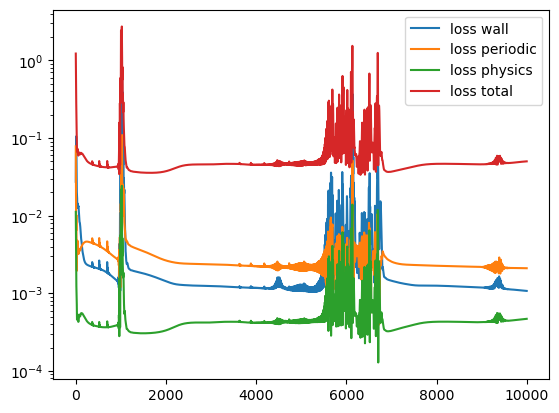

In [129]:
plt.plot(history["wall"], label = "loss wall")
plt.plot(history["periodic"], label = "loss periodic")
plt.plot(np.array(history["physics"])*0.01, label = "loss physics")
plt.plot(history["total"], label = "loss total")
plt.legend()
plt.yscale("log")

In [130]:
U= mlp_apply(trained_params, X_test)
np.where(X_test[:,2] ==5/9)[0]



array([  5,  15,  25,  35,  45,  55,  65,  75,  85,  95, 105, 115, 125,
       135, 145, 155, 165, 175, 185, 195, 205, 215, 225, 235, 245, 255,
       265, 275, 285, 295, 305, 315, 325, 335, 345, 355, 365, 375, 385,
       395, 405, 415, 425, 435, 445, 455, 465, 475, 485, 495, 505, 515,
       525, 535, 545, 555, 565, 575, 585, 595, 605, 615, 625, 635, 645,
       655, 665, 675, 685, 695, 705, 715, 725, 735, 745, 755, 765, 775,
       785, 795, 805, 815, 825, 835, 845, 855, 865, 875, 885, 895, 905,
       915, 925, 935, 945, 955, 965, 975, 985, 995], dtype=int64)

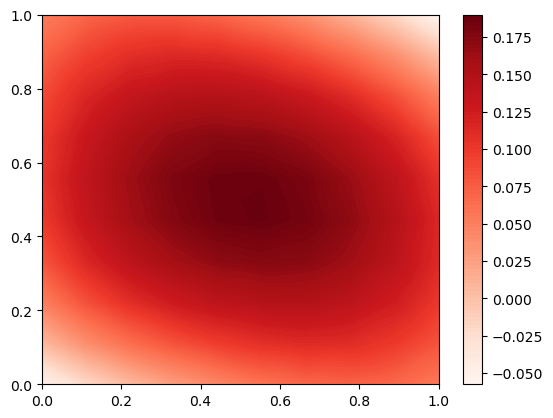

In [131]:
import matplotlib.pyplot as plt
_X_test = X_test[X_test[:,2] ==5/9]
i = np.where(X_test[:,2] ==5/9)[0]
f = plt.tricontourf(_X_test[:,0],_X_test[:,1], U[i,0], levels = 100, cmap="Reds")
plt.colorbar(f)

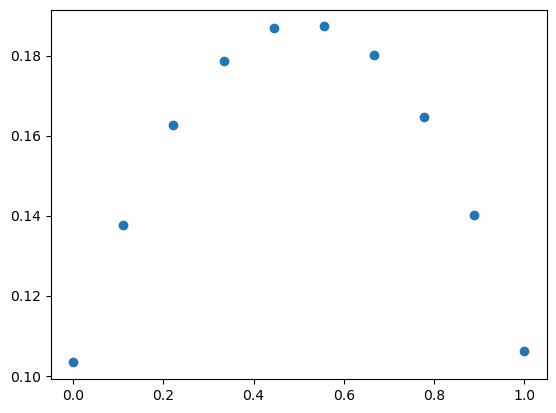

In [132]:
__X_test = _X_test[_X_test[:,1] == 5/9]
ii = np.where((X_test[:,2] ==5/9)&(X_test[:,1] ==5/9))[0]
plt.scatter(__X_test[:,0], U[ii,0])

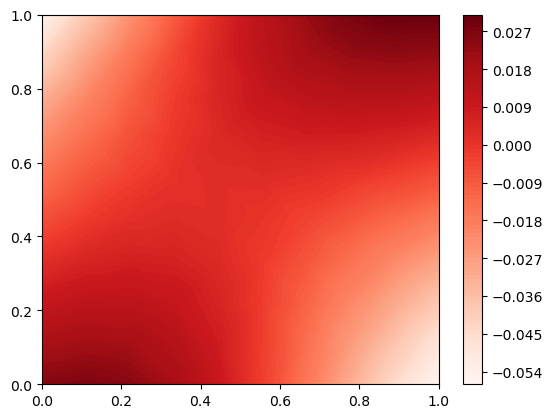

In [133]:
f = plt.tricontourf(_X_test[:,0],_X_test[:,1], U[i,1], levels = 100, cmap="Reds")
plt.colorbar(f)

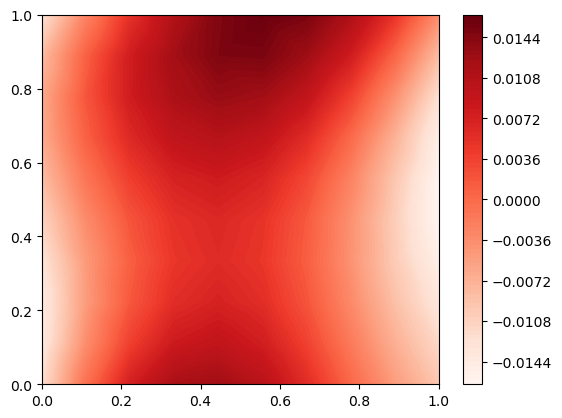

In [134]:
f = plt.tricontourf(_X_test[:,0],_X_test[:,1], U[i,2], levels = 100, cmap="Reds")
plt.colorbar(f)

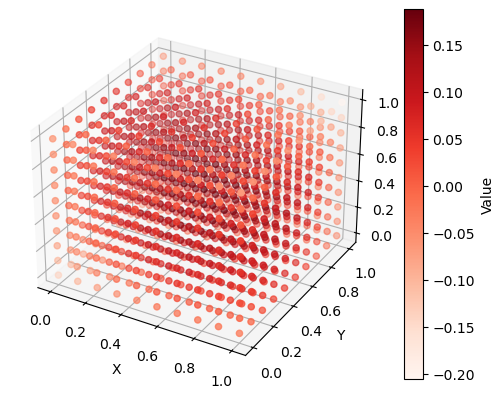

In [136]:

# --- 3Dプロット ---
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# --- 散布図を描画（色を values に対応）---
sc = ax.scatter(X_test[:,0], X_test[:,1], X_test[:,2], c=U[:,0], cmap='Reds')  # 他にも 'plasma', 'coolwarm' など可

# --- カラーバーを追加 ---
plt.colorbar(sc, ax=ax, label='Value')

# --- 軸ラベル ---
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()
